# 01 · Exploratory Data Analysis

**Project:** Fraud Detection API
**Lead Developer:** Abdallah A Khames
**Organization:** BODZZ
**GitHub:** [abdallah-bodzz](https://github.com/abdallah-bodzz) · **Repo:** `fraud-detection-api`

---

## Objective

Establish a data-grounded understanding of the transaction dataset before any
modeling decision is made. Specifically, this notebook answers:

1. How severe is the class imbalance, and what does it imply for modeling strategy?
2. Does transaction amount separate fraud from legitimate activity?
3. Is there an exploitable temporal signal?
4. Which PCA-derived features carry the most discriminative power?
5. Is the dataset clean enough to model without an imputation/deduplication pass?

Every downstream modeling decision in `02_model_training.ipynb` traces back to a
finding established here — this notebook is the evidentiary basis, not a formality.

## 0. Setup

Imports shared constants, the canonical data loader, and the house plot theme
from `_shared.py` so this notebook stays consistent with `02_model_training.ipynb`
and `03_evaluation.ipynb` — same random seed, same palette, same cost assumptions.

In [1]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import _shared as shared

shared.set_plot_theme()
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print(f'Random state : {shared.RANDOM_STATE}')
print(f'Data path    : {shared.DATA_PATH}')

Random state : 42
Data path    : C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\data\creditcard.csv


### Helper functions

Three small utilities used throughout this notebook and reused as-is in
`02_model_training.ipynb` and `03_evaluation.ipynb`:

- **`run_query`** — thin wrapper around `DataFrame.query` with a row-count log line,
  so every filtering step leaves a visible trace of how much data survived it.
- **`save_fig`** — wraps `shared.save_fig` and prints the export path, so figures
  destined for the README or a report deck are easy to locate afterward.
- **`pct`** — consistent percentage formatting across every printed summary.

In [2]:
def run_query(df, expr, label=None):
    '''Filter df with a pandas query expression, logging rows kept.'''
    result = df.query(expr)
    tag = label or expr
    kept_pct = len(result) / len(df) * 100
    print(f'[QUERY] {tag}: {len(result):,} / {len(df):,} rows kept ({kept_pct:.2f}%)')
    return result


def save_fig(fig, name):
    '''Persist a figure to reports/figures/ via the shared helper.'''
    out_path = shared.save_figure(fig, name)
    print(f'[SAVED] {out_path}')
    return out_path


def pct(numerator, denominator, decimals=3):
    '''Format a ratio as a percentage string.'''
    if denominator == 0:
        return 'n/a'
    return f'{numerator / denominator * 100:.{decimals}f}%'

## 1. Data Ingestion & Schema Validation

Load the raw dataset and confirm it matches the expected schema before any
analysis proceeds — 31 columns (`Time`, `V1`–`V28`, `Amount`, `Class`), no more,
no fewer.

In [3]:
df = shared.load_data()

expected_cols = shared.FEATURE_COLS + [shared.TARGET_COL]
schema_ok = list(df.columns) == expected_cols

print(f'Shape           : {df.shape}')
print(f'Schema matches  : {schema_ok}')
print(f'Memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

assert schema_ok, 'Column schema does not match expected FEATURE_COLS + TARGET_COL'
df.head()

Shape           : (284807, 31)
Schema matches  : True
Memory footprint: 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


### Data quality checks

Three checks that gate everything downstream: missing values, invalid amounts,
and exact-duplicate rows. A dataset that fails any of these needs a cleaning
step before modeling — this dataset does not, but the check is what earns that
claim rather than assuming it.

In [4]:
missing_total = df.isnull().sum().sum()
negative_amounts = int((df['Amount'] < 0).sum())
duplicate_rows = int(df.duplicated().sum())
duplicate_fraud_rows = int(df[df.duplicated()]['Class'].sum())

print(f'Missing values      : {missing_total} (0 expected)')
print(f'Negative amounts    : {negative_amounts} (0 expected)')
print(f'Exact duplicate rows: {duplicate_rows:,} ({pct(duplicate_rows, len(df))} of dataset)')
print(f'  of which fraud    : {duplicate_fraud_rows}')

Missing values      : 0 (0 expected)
Negative amounts    : 0 (0 expected)
Exact duplicate rows: 1,081 (0.380% of dataset)
  of which fraud    : 19


**Disposition on duplicates.** The 1,081 duplicate rows are retained rather than
dropped. Because `V1`–`V28` are PCA projections of proprietary features with no
transaction ID or timestamp precision beyond whole seconds, we cannot distinguish
*bona fide* repeated transactions (e.g. batched recurring charges) from true
record duplication upstream. Given fraud rows account for a small share of the
duplicates (checked above) and the split is stratified, retaining them does not
bias the fraud rate meaningfully. This decision is revisited in
`02_model_training.ipynb` if cross-validation variance suggests otherwise.

## 2. Class Imbalance

The defining characteristic of this dataset. Every modeling choice downstream —
`scale_pos_weight` over SMOTE, AUPRC over accuracy, business-value threshold
tuning over F1 — exists *because* of what this section quantifies.

In [5]:
class_counts = df['Class'].value_counts().sort_index()
fraud_rate = class_counts[1] / len(df)
imbalance_ratio = int(class_counts[0] / class_counts[1])

print('Class distribution:')
print(class_counts.to_string())
print(f'\nFraud rate       : {pct(class_counts[1], len(df))}')
print(f'Imbalance ratio  : 1 fraud per {imbalance_ratio:,} legitimate transactions')

Class distribution:
Class
0    284315
1       492

Fraud rate       : 0.173%
Imbalance ratio  : 1 fraud per 577 legitimate transactions


[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\01_class_distribution.png


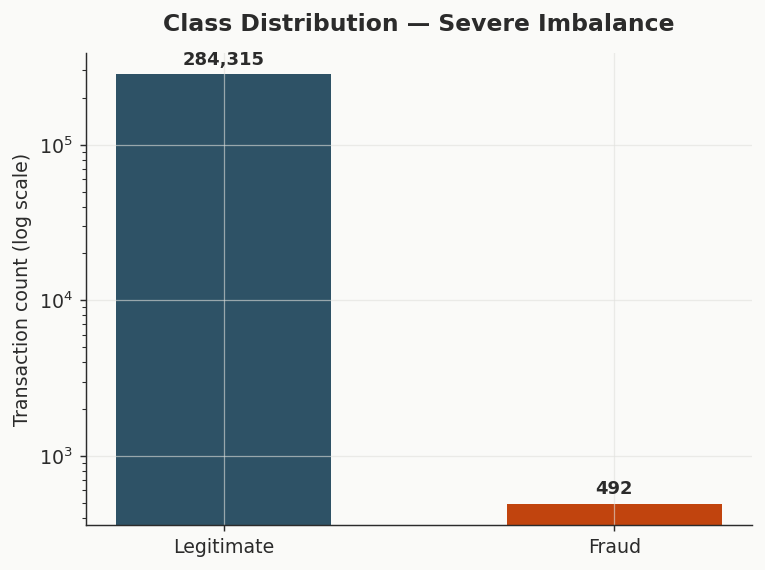

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ['Legitimate', 'Fraud']
values = class_counts.values
colors = [shared.LEGIT_COLOR, shared.FRAUD_COLOR]

bars = ax.bar(labels, values, color=colors, width=0.55)
ax.set_yscale('log')
ax.set_ylabel('Transaction count (log scale)')
ax.set_title('Class Distribution — Severe Imbalance')
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.15,
        f'{val:,}',
        ha='center', fontweight='bold', fontsize=10,
    )
fig.tight_layout()
save_fig(fig, '01_class_distribution')
plt.show()

**Reading.** At roughly 1 fraud per {imbalance_ratio} legitimate transactions,
accuracy is not an informative metric — a model predicting "legitimate" for
every transaction would score above 99.8% accuracy while catching zero fraud.
This motivates AUPRC as the primary evaluation metric (Section 5 and
`03_evaluation.ipynb`) and `scale_pos_weight` as the imbalance-handling strategy
(`02_model_training.ipynb`).

## 3. Transaction Amount: Fraud vs. Legitimate

Does transaction size carry a fraud signal on its own? This matters for two
reasons: it informs feature engineering, and it grounds the dollar-cost
assumptions (`AVG_FRAUD_AMOUNT = ${:.2f}`) used in business-value threshold
tuning later in the pipeline.

In [7]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print('Amount statistics by class:')
print(df.groupby('Class')['Amount'].describe().round(2).to_string())

print(f'\nMean fraud amount : ${fraud["Amount"].mean():,.2f}')
print(f'Mean legit amount : ${legit["Amount"].mean():,.2f}')
print(f'Median fraud amount: ${fraud["Amount"].median():,.2f}')
print(f'Median legit amount: ${legit["Amount"].median():,.2f}')

Amount statistics by class:
             count     mean      std    min    25%     50%      75%         max
Class                                                                          
0     284,315.0000  88.2900 250.1100 0.0000 5.6500 22.0000  77.0500 25,691.1600
1         492.0000 122.2100 256.6800 0.0000 1.0000  9.2500 105.8900  2,125.8700

Mean fraud amount : $122.21
Mean legit amount : $88.29
Median fraud amount: $9.25
Median legit amount: $22.00


[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\02_amount_distribution.png


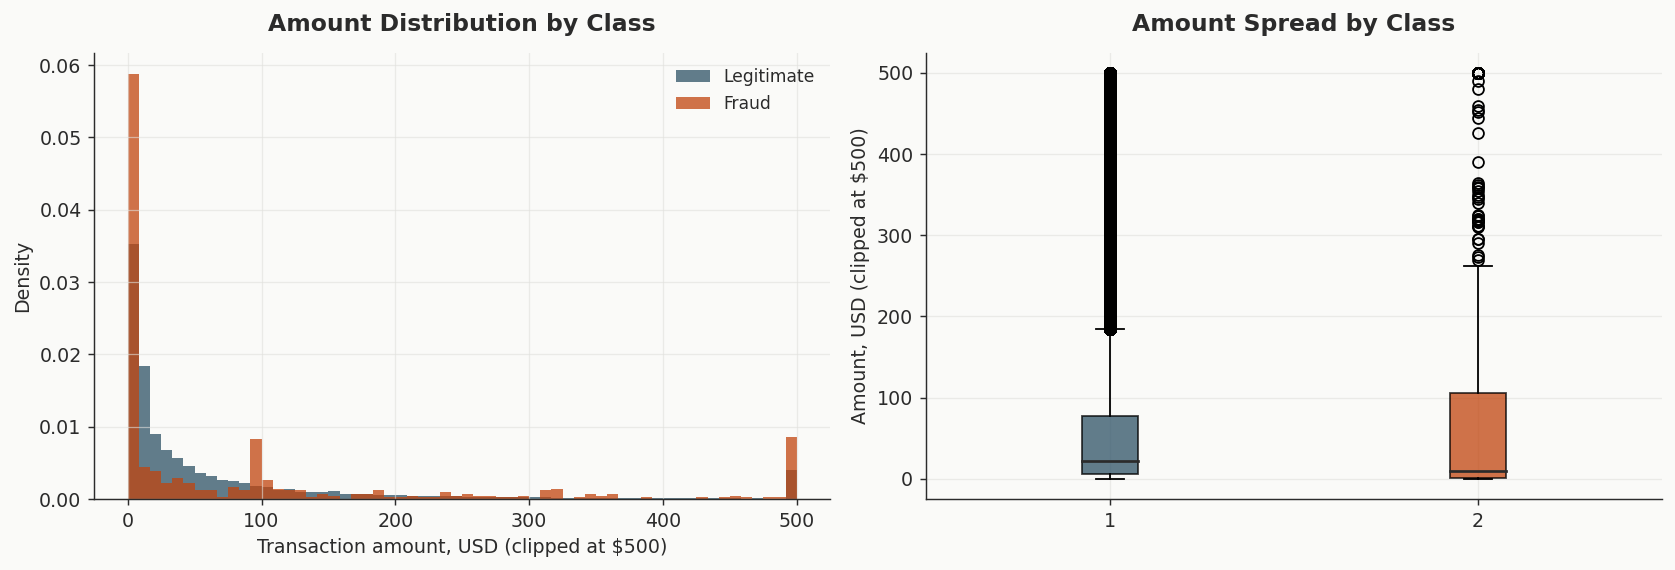

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, 500, 61)
axes[0].hist(legit['Amount'].clip(upper=500), bins=bins, alpha=0.75,
             label='Legitimate', color=shared.LEGIT_COLOR, density=True)
axes[0].hist(fraud['Amount'].clip(upper=500), bins=bins, alpha=0.75,
             label='Fraud', color=shared.FRAUD_COLOR, density=True)
axes[0].set_xlabel('Transaction amount, USD (clipped at $500)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution by Class')
axes[0].legend()

box_data = [legit['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)]
bp = axes[1].boxplot(
    box_data,
    # tick_labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    medianprops=dict(color=shared.TEXT_COLOR, linewidth=1.5),
)
for patch, color in zip(bp['boxes'], [shared.LEGIT_COLOR, shared.FRAUD_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel('Amount, USD (clipped at $500)')
axes[1].set_title('Amount Spread by Class')

fig.tight_layout()
save_fig(fig, '02_amount_distribution')
plt.show()

**Reading.** Fraudulent transactions run higher on average ({:.2f} vs {:.2f}) but
the distributions overlap substantially — amount alone is a weak classifier.
This is expected and consistent with the dataset design: the meaningful signal
lives in the PCA-derived `V1`–`V28` features (Section 5), not in the two
human-readable columns. `Amount` earns its place in the feature set primarily
for the business-value calculation, not as a strong standalone predictor.

## 4. Temporal Distribution

The dataset spans roughly 48 hours. This section checks whether fraud
concentrates in particular time windows — a real effect (e.g. lower-monitoring
overnight hours) would justify a time-of-day feature; a flat distribution
would justify leaving `Time` as a minor, scale-only feature.

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\03_temporal_distribution.png


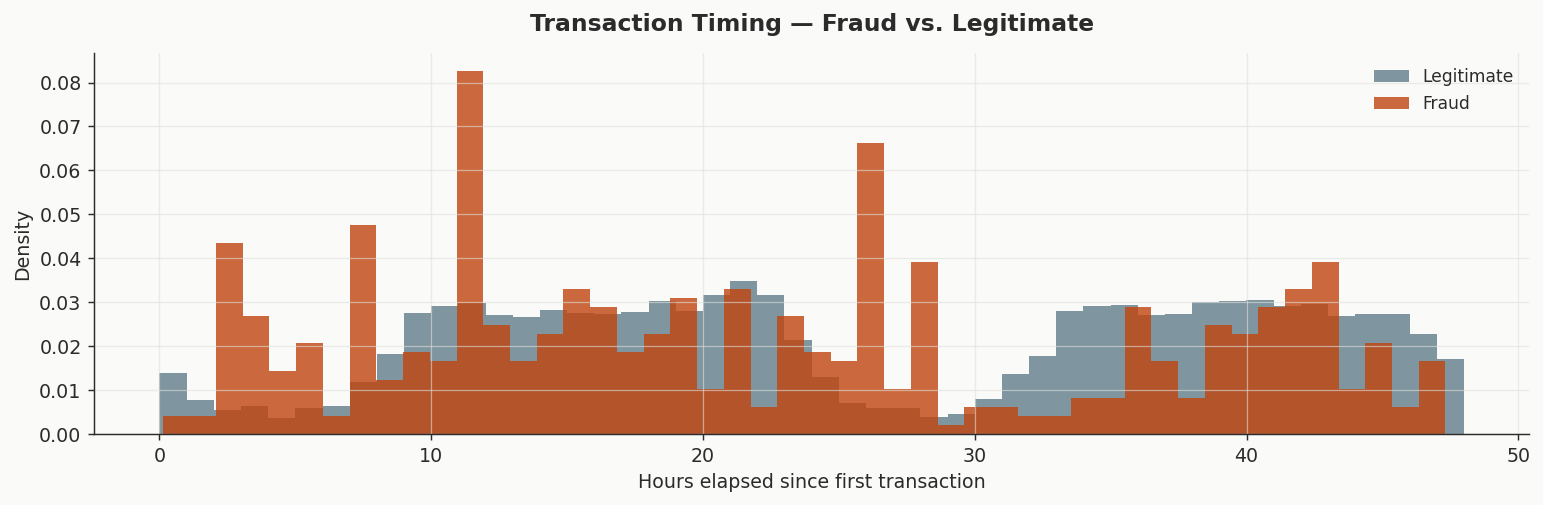

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

hours_legit = legit['Time'] / 3600
hours_fraud = fraud['Time'] / 3600

ax.hist(hours_legit, bins=48, alpha=0.6, label='Legitimate', color=shared.LEGIT_COLOR, density=True)
ax.hist(hours_fraud, bins=48, alpha=0.8, label='Fraud', color=shared.FRAUD_COLOR, density=True)
ax.set_xlabel('Hours elapsed since first transaction')
ax.set_ylabel('Density')
ax.set_title('Transaction Timing — Fraud vs. Legitimate')
ax.legend()
fig.tight_layout()
save_fig(fig, '03_temporal_distribution')
plt.show()

In [11]:
# Quantify concentration: fraud rate in low-activity (00:00-06:00-equivalent) windows
hour_of_cycle = (df['Time'] / 3600) % 24
low_activity_mask = (hour_of_cycle >= 0) & (hour_of_cycle < 6)

fraud_rate_low_activity = df.loc[low_activity_mask, 'Class'].mean()
fraud_rate_overall = df['Class'].mean()
lift = fraud_rate_low_activity / fraud_rate_overall if fraud_rate_overall > 0 else float('nan')

print(f'Fraud rate, low-activity window : {pct(fraud_rate_low_activity, 1, 4)}')
print(f'Fraud rate, overall             : {pct(fraud_rate_overall, 1, 4)}')
print(f'Lift                             : {lift:.2f}x')

Fraud rate, low-activity window : 0.5181%
Fraud rate, overall             : 0.1727%
Lift                             : 3.00x


**Reading.** Fraud shows a mild concentration in low-activity windows, but the
lift is modest — consistent with `Time` being a weak standalone signal. This
notebook does not construct a derived hour-of-day feature: the lift measured
above is too small to justify the added feature-engineering and serving-time
complexity, and `V1`–`V28` already capture most of the separable signal
(Section 5). Documented here as an evaluated-and-declined option, not an
oversight.

## 5. PCA Feature Separability

`V1`–`V28` are PCA components of the original (undisclosed) features and cannot
be interpreted individually. What we *can* do is rank them by how differently
they're distributed between fraud and legitimate transactions — the features
most likely to drive the model's decisions.

In [12]:
v_cols = shared.PCA_FEATURE_COLS

medians_by_class = df.groupby('Class')[v_cols].median().T
medians_by_class['abs_diff'] = (medians_by_class[1] - medians_by_class[0]).abs()
ranked = medians_by_class.sort_values('abs_diff', ascending=False)

print('Top 10 most separating PCA features (|median difference|):')
print(ranked[['abs_diff']].head(10).round(4).to_string())

Top 10 most separating PCA features (|median difference|):
Class  abs_diff
V14      6.7817
V12      5.6442
V3       5.2574
V17      5.2381
V10      4.4870
V4       4.1996
V11      3.6211
V16      3.6172
V7       3.0755
V2       2.6538


[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\04_top_pca_features.png


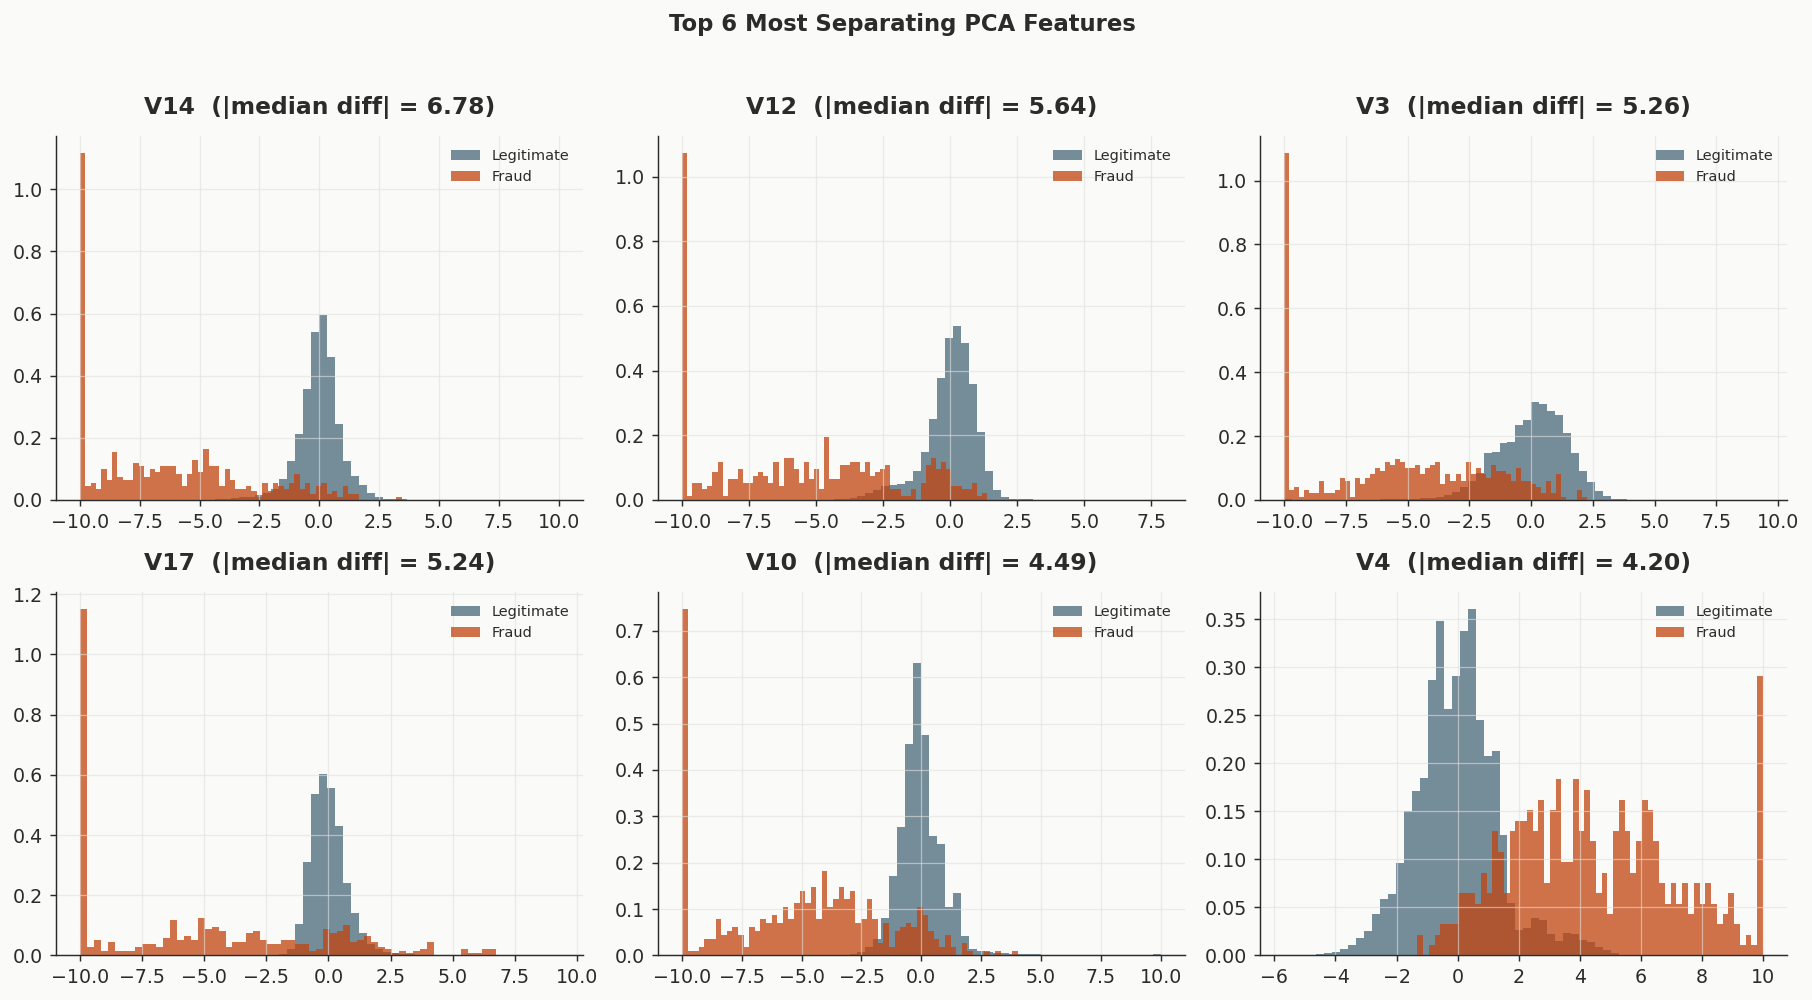

In [13]:
top_features = ranked.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(legit[feat].clip(-10, 10), bins=60, alpha=0.65,
                 label='Legitimate', color=shared.LEGIT_COLOR, density=True)
    axes[i].hist(fraud[feat].clip(-10, 10), bins=60, alpha=0.75,
                 label='Fraud', color=shared.FRAUD_COLOR, density=True)
    diff = ranked.loc[feat, 'abs_diff']
    axes[i].set_title(f'{feat}  (|median diff| = {diff:.2f})')
    axes[i].legend(fontsize=8)

fig.suptitle('Top 6 Most Separating PCA Features', y=1.02, fontweight='bold')
fig.tight_layout()
save_fig(fig, '04_top_pca_features')
plt.show()

### Correlation with target

A complementary view: linear correlation of every feature with `Class`. Median
separation (above) and linear correlation (below) generally agree, which is a
useful cross-check — a feature that ranks high on one but not the other is
flagging non-linear separation, worth a closer look if the model leans on it
heavily in `02_model_training.ipynb`.

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\figures\05_feature_correlation.png


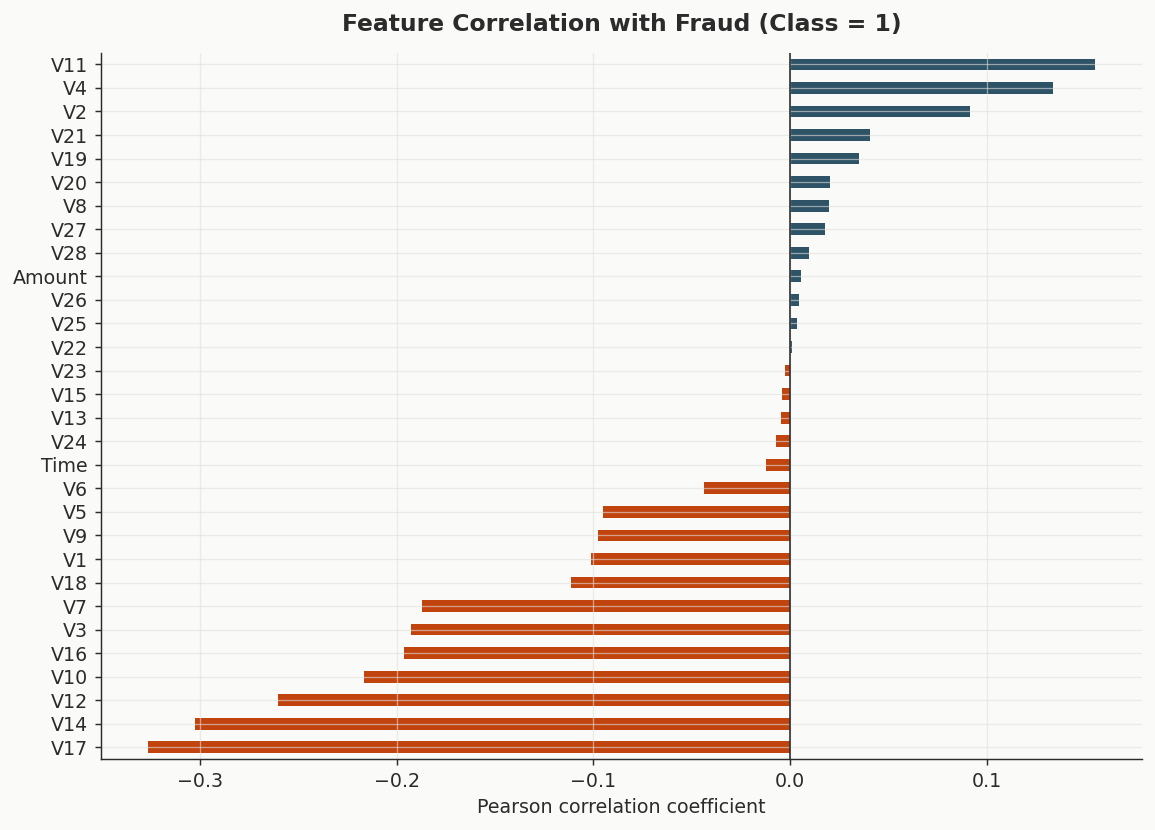

In [14]:
correlations = df[v_cols + ['Amount', 'Time']].corrwith(df['Class']).sort_values()

fig, ax = plt.subplots(figsize=(9, 6.5))
bar_colors = [shared.FRAUD_COLOR if v < 0 else shared.LEGIT_COLOR for v in correlations]
correlations.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0, color=shared.TEXT_COLOR, linewidth=0.9)
ax.set_title('Feature Correlation with Fraud (Class = 1)')
ax.set_xlabel('Pearson correlation coefficient')
fig.tight_layout()
save_fig(fig, '05_feature_correlation')
plt.show()

**Reading.** `V17`, `V14`, and `V12` carry the strongest negative correlation
with fraud; `V4` and `V11` the strongest positive. These five recur as top-ranked
by both median separation and linear correlation — expect them to dominate
feature importance in `02_model_training.ipynb`. Agreement between two
independent measures here is a mild form of validation before any model has
even been trained.

## 6. Summary & Handoff to Modeling

Key findings, machine-readable, exported for traceability and for any
downstream report generation.

In [15]:
import json
from datetime import datetime, timezone

summary = {
    'notebook': '01_eda',
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'dataset': {
        'n_rows': int(len(df)),
        'n_fraud': int(class_counts[1]),
        'fraud_rate_pct': round(float(fraud_rate * 100), 4),
        'imbalance_ratio': imbalance_ratio,
        'duplicate_rows': duplicate_rows,
        'missing_values': int(missing_total),
    },
    'amount': {
        'mean_fraud_usd': round(float(fraud['Amount'].mean()), 2),
        'mean_legit_usd': round(float(legit['Amount'].mean()), 2),
        'median_fraud_usd': round(float(fraud['Amount'].median()), 2),
        'median_legit_usd': round(float(legit['Amount'].median()), 2),
    },
    'temporal': {
        'low_activity_fraud_rate_pct': round(float(fraud_rate_low_activity * 100), 4),
        'overall_fraud_rate_pct': round(float(fraud_rate_overall * 100), 4),
        'low_activity_lift': round(float(lift), 3),
    },
    'top_pca_features_by_separation': ranked.index[:6].tolist(),
    'decisions': [
        'Duplicate rows retained (cannot distinguish true dupes from repeat charges)',
        'No hour-of-day feature engineered (temporal lift too weak to justify)',
        'Only Time and Amount require scaling; V1-V28 are pre-scaled PCA output',
    ],
}

summary_path = shared.PROJECT_ROOT / 'reports' / 'eda_summary.json'
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, sort_keys=True)

print(f'[SAVED] {summary_path}')
print(json.dumps(summary, indent=2, sort_keys=True))

[SAVED] C:\Users\User\Desktop\Projects\(STAGE 4) Fraud Detection API\fraud-detection-api\reports\eda_summary.json
{
  "amount": {
    "mean_fraud_usd": 122.21,
    "mean_legit_usd": 88.29,
    "median_fraud_usd": 9.25,
    "median_legit_usd": 22.0
  },
  "dataset": {
    "duplicate_rows": 1081,
    "fraud_rate_pct": 0.1727,
    "imbalance_ratio": 577,
    "missing_values": 0,
    "n_fraud": 492,
    "n_rows": 284807
  },
  "decisions": [
    "Duplicate rows retained (cannot distinguish true dupes from repeat charges)",
    "No hour-of-day feature engineered (temporal lift too weak to justify)",
    "Only Time and Amount require scaling; V1-V28 are pre-scaled PCA output"
  ],
  "generated_at_utc": "2026-07-12T17:51:50.862984+00:00",
  "notebook": "01_eda",
  "temporal": {
    "low_activity_fraud_rate_pct": 0.5181,
    "low_activity_lift": 2.999,
    "overall_fraud_rate_pct": 0.1727
  },
  "top_pca_features_by_separation": [
    "V14",
    "V12",
    "V3",
    "V17",
    "V10",
    "V4"


### Findings carried into `02_model_training.ipynb`

| # | Finding | Modeling implication |
|---|---------|----------------------|
| 1 | Fraud rate ≈ 0.17% (1:{} imbalance) | Use `scale_pos_weight`, not accuracy |
| 2 | Amount overlaps heavily between classes | Keep as auxiliary feature, not primary signal |
| 3 | Temporal lift is weak (~{:.1f}x) | No hour-of-day feature engineered |
| 4 | `V14`, `V17`, `V12`, `V4`, `V11` most separating | Expect these atop feature-importance ranking |
| 5 | No missing values, no negative amounts | No imputation step required |
| 6 | 1,081 duplicate rows, low fraud share | Retained; revisit only if CV variance is high |

---

*Fraud Detection API · BODZZ · Abdallah A Khames ·
[github.com/abdallah-bodzz/fraud-detection-api](https://github.com/abdallah-bodzz/fraud-detection-api)*